---

## Human-in-the-Loop

고위험 작업에 대해 인간 승인을 요청하는 흐름을 도입합니다. 중요한 결정이나 민감한 작업 수행 전에 사람의 확인을 받을 수 있어 AI 시스템의 안전성을 높입니다.

> 📖 **참고 문서**: [LangGraph Interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| interrupt | 그래프 실행을 일시정지하고 외부 입력을 대기 |
| Command | 승인/거부 후 재개 명령을 전달하는 객체 |
| Human Approval | 사람이 검토하고 승인하는 워크플로우 |

아래 코드는 사람의 도움을 요청하는 도구를 정의합니다.

In [1]:
from feature.HumanIntheLoopUseCommandResume import HumanIntheLoopUseCommand

workflow = HumanIntheLoopUseCommand()

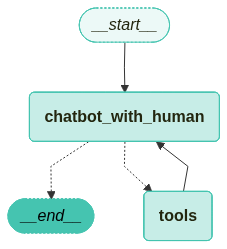

In [2]:
workflow.show_graph()

In [2]:
from util.messages import random_uuid
from langchain_core.messages import HumanMessage

# 인간 지원을 요청하는 메시지
user_input = "LangGraph 가 뭐야? 사람한테 듣고 싶어."
config_hitl = {"configurable": {"thread_id": random_uuid()}}

print(f"User: {user_input}\n")


workflow.stream(
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=config_hitl,
)


User: LangGraph 가 뭐야? 사람한테 듣고 싶어.


🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [8]:
# 상태 확인 - 어느 노드에서 중단되었는지 확인
snapshot = workflow.graph.get_state(config_hitl)

print(f"  다음 실행할 노드: {snapshot.next}")
print(f"  체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")



from langchain_teddynote.messages import display_message_tree

display_message_tree(snapshot.values['messages'][-1])

  다음 실행할 노드: ('tools',)
  체크포인트 ID: 1f14e947-a7ac-690c-8001-098019a435cc
    content: ""
    additional_kwargs: {}
    response_metadata: {"finish_reason": "tool_calls", "model_name": "gpt-4o-mini-2024-07-18", "system_fingerprint": "fp_5c05ed2f37", "service_tier": "default", "model_provider": "openai"}
    type: "ai"
    name: None
    id: "lc_run--019e2002-a002-7b30-b0c2-bb0d7477bda5"
    tool_calls:
        index [0]
            name: "human_assistance"
            args: {"query": "LangGraph가 무엇인지 설명해 주세요."}
            id: "call_5T79iVxYFvIwcORSO8q22lwV"
            type: "tool_call"
    invalid_tool_calls:
    usage_metadata:
        input_tokens: 60
        output_tokens: 24
        total_tokens: 84
        input_token_details: {"audio": 0, "cache_read": 0}
        output_token_details: {"audio": 0, "reasoning": 0}


In [9]:
from langgraph.types import Command, interrupt


# 인간의 응답으로 실행 재개
human_response = """## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)
"""

# Command 객체로 재개
human_command = Command(resume={"data": human_response})

print(f"\n사람의 응답: {human_response}\n")

# 재개
workflow.stream(inputs=human_command, config=config_hitl)


사람의 응답: ## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)


{'data': '## 전문가의 조언:\n- YouTube 테디노트: https://www.youtube.com/c/teddynote\n- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)\n'}

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)

🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
LangGraph에 대한 정보를 얻기 위해 전문가에게 문의한 결과, 관련 자료를 추천받았습니다. YouTube 채널 "테디노트"와 패스트캠퍼스의 고급 개발자 강의 "RAG 비법노트"를 참고하시면 LangGraph에 대한 더 깊은 이해를 얻으실 수 있습니다. 

1. [테디노트 YouTube 채널](https://www.youtube.com/c/teddynote)
2. [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)

이 자료들을 통해 LangGraph에 대해 자세히 알아보세요!